In [1]:
from pathlib import Path
import sys
project_root = Path.cwd().resolve().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from Data.dataset import MVTecDataset
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader

data_path = project_root / "Data" / "mvtec" / "bottle"

In [2]:
bottle_dataset = MVTecDataset(root_dir=data_path, split="train", return_mask=False)

In [3]:
len(bottle_dataset)

209

In [4]:
sample = bottle_dataset[0]
sample

{'image': tensor([[[2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          ...,
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489],
          [2.2489, 2.2489, 2.2489,  ..., 2.2489, 2.2489, 2.2489]],
 
         [[2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          ...,
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286],
          [2.4286, 2.4286, 2.4286,  ..., 2.4286, 2.4286, 2.4286]],
 
         [[2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
          [2.6400, 2.6400, 2.6400,  ..., 2.6400, 2.6400, 2.6400],
          [2.6400, 2.6400, 2.64

In [5]:
image_tensor = sample["image"]
image_tensor.shape

torch.Size([3, 256, 256])

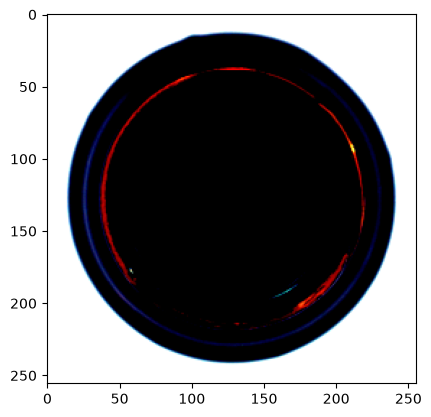

In [6]:
image_np = image_tensor.permute(1, 2, 0).numpy()
image_np = np.clip(image_np, 0, 1)
plt.imshow(image_np)

In [7]:
loader = DataLoader(bottle_dataset, batch_size=4)

In [15]:
sample = next(iter(loader))

In [16]:
images = sample["image"]
print(images.shape)

torch.Size([4, 3, 256, 256])


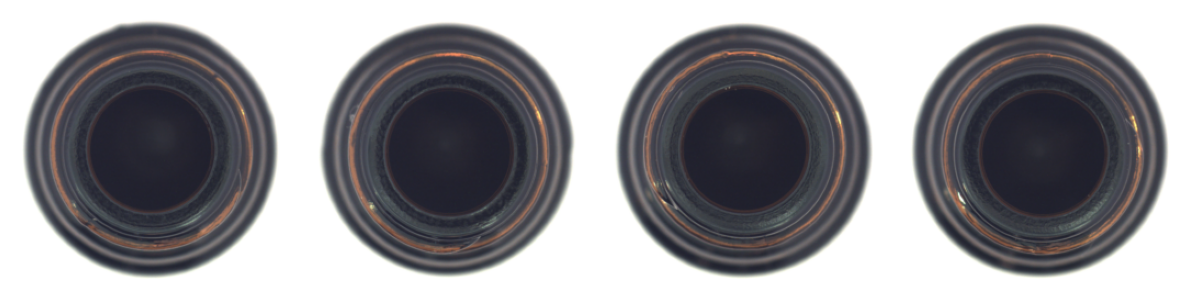

In [19]:
mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)

fig, axes = plt.subplots(1, 4, figsize=(12, 4))

for i in range(4):
    img = images[i] * std + mean  
    img = torch.clamp(img, 0, 1)
    axes[i].imshow(img.permute(1, 2, 0))
    axes[i].axis("off")

plt.tight_layout()
plt.show()